## Useful functions

You don't need to change these functions, and you don't have to necessarilty use them to complete your assignment. 

In [1]:
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from sklearn.metrics import recall_score, precision_score, f1_score
from sklearn.preprocessing import StandardScaler
import numpy as np


# plot one or more features (using separate plots) for a start and end date, if y is set then it shows the anomalies
#  (could be predicted or real if ground truth used)
def plot_features(df, start_day, start_year, end_day, end_year, features, y=None):
    # Filter the period
    mask = (
        (df['year'] > start_year) | 
        ((df['year'] == start_year) & (df['day_of_year'] >= start_day))
    ) & (
        (df['year'] < end_year) | 
        ((df['year'] == end_year) & (df['day_of_year'] <= end_day))
    )
    df_period = df[mask].copy()
    df_period = df_period.reset_index(drop=False)  # Keep original indices for mapping y
    df_period['date'] = pd.to_datetime(
        df_period['year'].astype(int).astype(str) + df_period['day_of_year'].astype(int).astype(str).str.zfill(3), format='%Y%j')

    if isinstance(features, str):
        features = [features]

    for feature in features:
        plt.figure(figsize=(10, 4))

        # If y is provided, plot anomalies
        if y is not None:
            anomaly_indices = df_period[df_period['index'].map(lambda idx: y[idx] == -1)].index
            plt.scatter(
                df_period.loc[anomaly_indices, 'date'],
                df_period.loc[anomaly_indices, feature],
                color='red', marker='*', s=120, label='Anomaly'
            )
            plt.legend()
        plt.plot(df_period['date'], df_period[feature], marker='o', linestyle='-')

        plt.title(f'{feature} over time')
        plt.xlabel('Date')
        plt.ylabel(feature)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# show a summary of the dataset, not crucial, but useful to understand the data
def print_summary(y_true):
    total = len(y_true)
    n_anomalies = (y_true == -1).sum()
    n_normals = (y_true == 1).sum()

    print("Dataset Summary:")
    print(f"Total instances:         {total}")
    print(f"Normal instances (1):    {n_normals}")
    print(f"Anomalous instances (-1): {n_anomalies}")
    print(f"Anomaly ratio:           {n_anomalies / total:.3%}")

# plot detections, useful when you already have the predictions and want to observe then on the data for each feature
def plot_detection(df, y_true, y_pred, start_day, start_year, end_day, end_year, feature):
    mask = (
        (df['year'] > start_year) | 
        ((df['year'] == start_year) & (df['day_of_year'] >= start_day))
    ) & (
        (df['year'] < end_year) | 
        ((df['year'] == end_year) & (df['day_of_year'] <= end_day))
    )
    df_period = df[mask].copy()
    idx_period = df_period.index
    df_period['date'] = pd.to_datetime(
    df_period['year'].astype(int).astype(str) + df_period['day_of_year'].astype(int).astype(str).str.zfill(3), format='%Y%j')
    y_true_period = y_true[idx_period]
    y_pred_period = y_pred[idx_period]

    correct = (y_true_period == -1) &  (y_pred_period == -1)
    missed = (y_true_period == -1) & (y_pred_period != -1)
    false_pos = (y_true_period != -1) & (y_pred_period == -1)

    plt.figure(figsize=(10, 4))
    plt.scatter(df_period.loc[correct, 'date'], df_period.loc[correct, feature], 
                marker='*', s=120, color='green', label='Correct Anomaly')
    plt.scatter(df_period.loc[missed, 'date'], df_period.loc[missed, feature], 
                marker='*', s=120, color='red', label='Missed Anomaly')
    plt.scatter(df_period.loc[false_pos, 'date'], df_period.loc[false_pos, feature], 
                marker='*', s=120, color='orange', label='False Positive')
    plt.plot(df_period['date'], df_period[feature], label=feature, color='blue', linestyle='-')

    plt.title(f'{feature} with Detected Anomalies')
    plt.xlabel('Date')
    plt.ylabel(feature)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# to facilitate the visualization of the results for the anomaly detection methods in part 1
def evaluate_predictions(y_true, y_pred, model_name="unnamed", header=True):
    # convert from -1 to 1 (1 for anomaly, 0 for normal) for evaluating
    y_true_binary = (y_true == -1).astype(int)
    y_pred_binary = (y_pred == -1).astype(int)

    recall = recall_score(y_true_binary, y_pred_binary)
    precision = precision_score(y_true_binary, y_pred_binary)
    f1 = f1_score(y_true_binary, y_pred_binary)

    correct = (y_true == -1) & (y_pred == -1)
    missed = (y_true == -1) & (y_pred != -1)
    false_positives = (y_true != -1) & (y_pred == -1)

    if header:
        print("| Model | Recall | Precision | F1 | Correct | Missed | False Positives |")
        print("|-------|--------|-----------|----|---------|--------|-----------------|")
    
    print(f"| {model_name} | {recall:.3f} | {precision:.3f} | {f1:.3f} | {correct.sum()} | {missed.sum()} | {false_positives.sum()} |")

## Example: reading and visualizing the data

In [2]:
import os
import pandas as pd

# Loading the data. y2122 contains the 'labels'
df2122 = None
y2122 = None

# Check and load if files exist
if os.path.exists("GenSyn2122.csv") and os.path.exists("GenSyn_labels2122.csv"):
    print("Loading GenSyn2122 dataset...")
    df2122 = pd.read_csv("GenSyn2122.csv")
    # -1 = anomaly, 1 = normal
    y2122 = pd.read_csv("GenSyn_labels2122.csv")['anomaly_label'].values

# Visualise part of the data...
# plot_features(df2122, 1, 2021, 100, 2021, ['temperature','energy_usage', 'season'])
display(df2122)
print("Missing value = "+str(df2122.isnull().values.any()))

Loading GenSyn2122 dataset...


,year,day_of_year,season,temperature,humidity,energy_usage
0,2021,1,summer,19.708638,78.625889,11.731837
1,2021,2,summer,20.703554,78.350411,13.453957
2,2021,3,summer,21.339178,82.736788,15.393096
3,2021,4,summer,20.823304,79.921728,16.657684
4,2021,5,summer,22.277698,80.406175,16.927320
...,...,...,...,...,...,...
725,2022,361,summer,24.648768,79.422802,18.579817
726,2022,362,summer,24.362897,80.541095,19.394421
727,2022,363,summer,24.730546,85.748327,20.060006
728,2022,364,summer,26.975549,81.506959,20.840548


Missing value = False


### Example: Using function evaluate_predictions

In [3]:
# evaluate_predictions(y_true=y2122, y_pred=the predictions of your model, model_name="name of the model", header=True):
# for example, if we use the ground truth to evaluate. You can past the result on a markdown cell to get a nice looking table
evaluate_predictions(y_true=y2122, y_pred=y2122, model_name="example", header=True)

| Model | Recall | Precision | F1 | Correct | Missed | False Positives |
|-------|--------|-----------|----|---------|--------|-----------------|
| example | 1.000 | 1.000 | 1.000 | 18 | 0 | 0 |


### Example: plotting anomalies using plot_detection

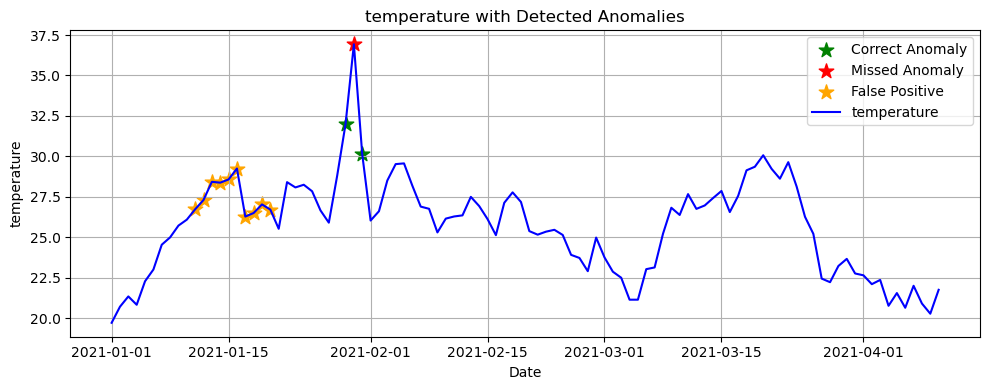

In [4]:
# generating some fake predictions for the plot
fake_preds=y2122.copy()
fake_preds[10:20] = -1
fake_preds[29] = 1
plot_detection(df=df2122, y_true=y2122, y_pred=fake_preds, start_day=1, start_year=2021, end_day=100, end_year=2021, feature="temperature")

### Example: using function plot_features

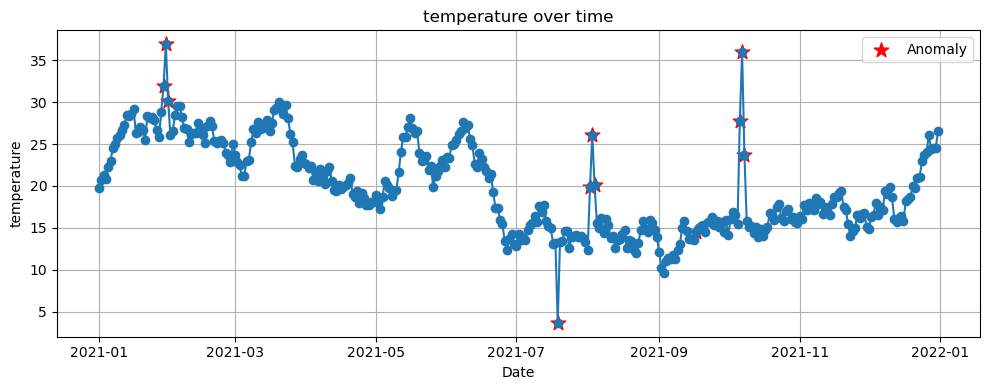

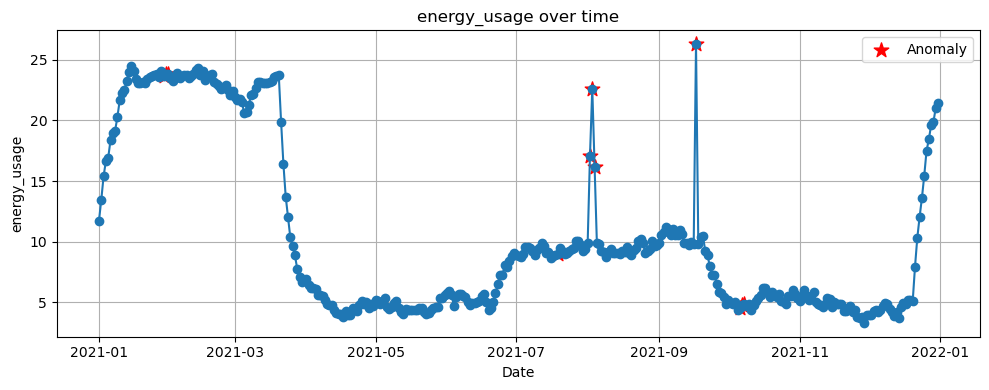

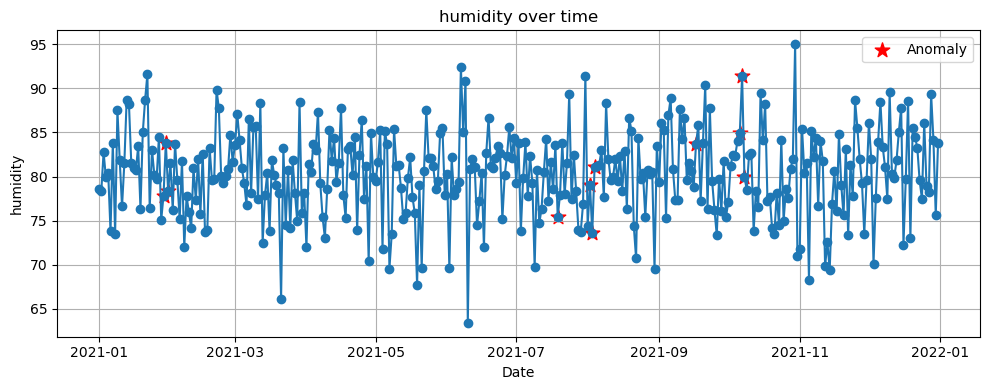

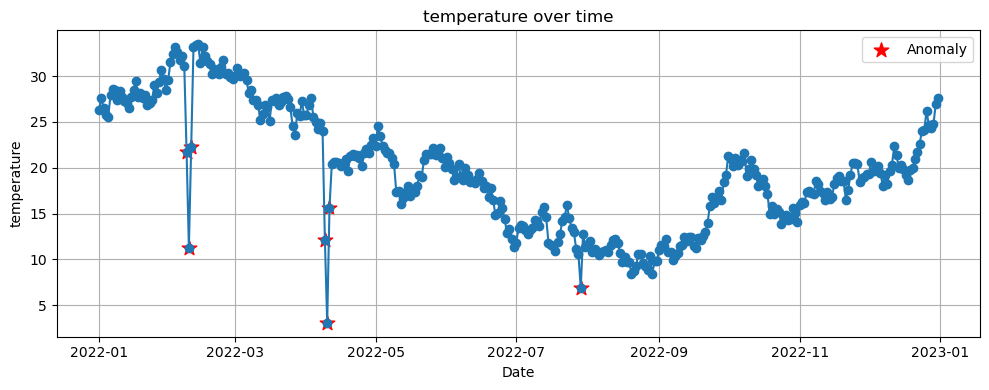

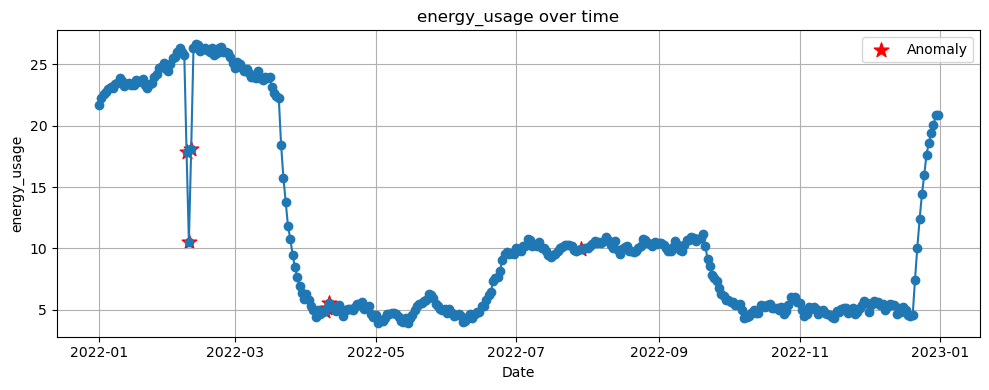

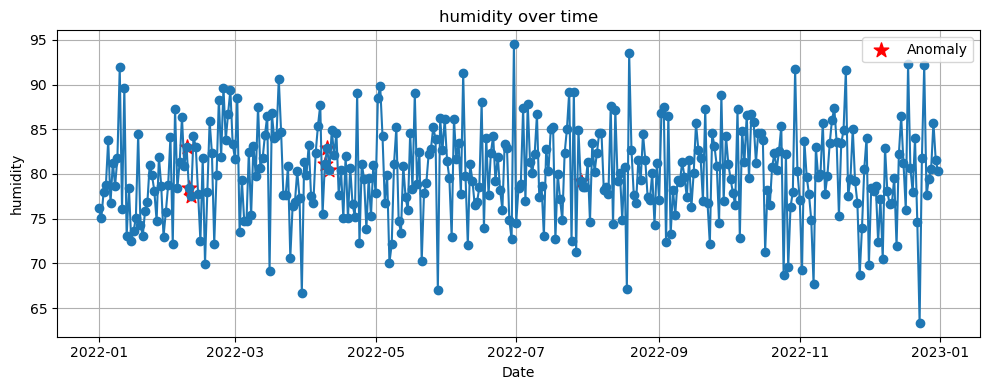

In [5]:
plot_features(df=df2122, y=y2122, start_day=1, start_year=2021, end_day=365, end_year=2021, features=["temperature", "energy_usage","humidity"])
plot_features(df=df2122, y=y2122, start_day=1, start_year=2022, end_day=365, end_year=2022, features=["temperature", "energy_usage","humidity"])

### Statistics about the anomalies

In [6]:
print_summary(y2122)

Dataset Summary:
Total instances:         730
Normal instances (1):    712
Anomalous instances (-1): 18
Anomaly ratio:           2.466%


# Part 1: Anomaly detection
## <span style="color: red; font-weight: 700;">Your answers should start here!</span>

Use the provided functions to help you, if you want to code your own plotting functions, feel free to do so!

## a) Preprossesing
The year variable was removed because it does not provide meaningful information for the clustering analysis and may introduce unnecessary variation between the two years.

In [7]:
df_original = df2122.copy()
df2122.drop(columns=["year"], inplace=True)
display(df2122)

,day_of_year,season,temperature,humidity,energy_usage
0,1,summer,19.708638,78.625889,11.731837
1,2,summer,20.703554,78.350411,13.453957
2,3,summer,21.339178,82.736788,15.393096
3,4,summer,20.823304,79.921728,16.657684
4,5,summer,22.277698,80.406175,16.927320
...,...,...,...,...,...
725,361,summer,24.648768,79.422802,18.579817
726,362,summer,24.362897,80.541095,19.394421
727,363,summer,24.730546,85.748327,20.060006
728,364,summer,26.975549,81.506959,20.840548


Sine transformation was used for the day of the year to capture its continuous cyclical pattern, where the value changes gradually from one day to the next while preserving the relative distance between days. The day variable captures the repeating yearly cycle through a sine transformation, allowing the continuous progression of days and the recurring annual pattern to be represented without explicitly including the year variable.

In [8]:
df2122["day_sin"] = np.sin(2 * np.pi * df2122["day_of_year"] / 365)
df2122 = df2122.drop(columns=["day_of_year"])
display(df2122)

,season,temperature,humidity,energy_usage,day_sin
0,summer,19.708638,78.625889,11.731837,1.721336e-02
1,summer,20.703554,78.350411,13.453957,3.442161e-02
2,summer,21.339178,82.736788,15.393096,5.161967e-02
3,summer,20.823304,79.921728,16.657684,6.880243e-02
4,summer,22.277698,80.406175,16.927320,8.596480e-02
...,...,...,...,...,...
725,summer,24.648768,79.422802,18.579817,-6.880243e-02
726,summer,24.362897,80.541095,19.394421,-5.161967e-02
727,summer,24.730546,85.748327,20.060006,-3.442161e-02
728,summer,26.975549,81.506959,20.840548,-1.721336e-02


For the season variable, I use sine and cosine transformations to capture the cyclical continuity of the seasons and represent the contrast between different seasons, such as the opposite relationship between summer and winter.

In [9]:
season_map = {
    "summer": 0,
    "autumn": 1,
    "winter": 2,
    "spring": 3
}

df2122["season_num"] = df2122["season"].str.lower().map(season_map)

df2122["season_sin"] = np.sin(2 * np.pi * df2122["season_num"] / 4)
df2122["season_cos"] = np.cos(2 * np.pi * df2122["season_num"] / 4)

df2122 = df2122.drop(columns=["season", "season_num"])
display(df2122)

,temperature,humidity,energy_usage,day_sin,season_sin,season_cos
0,19.708638,78.625889,11.731837,1.721336e-02,0.0,1.0
1,20.703554,78.350411,13.453957,3.442161e-02,0.0,1.0
2,21.339178,82.736788,15.393096,5.161967e-02,0.0,1.0
3,20.823304,79.921728,16.657684,6.880243e-02,0.0,1.0
4,22.277698,80.406175,16.927320,8.596480e-02,0.0,1.0
...,...,...,...,...,...,...
725,24.648768,79.422802,18.579817,-6.880243e-02,0.0,1.0
726,24.362897,80.541095,19.394421,-5.161967e-02,0.0,1.0
727,24.730546,85.748327,20.060006,-3.442161e-02,0.0,1.0
728,26.975549,81.506959,20.840548,-1.721336e-02,0.0,1.0


## b)IF vsLOF

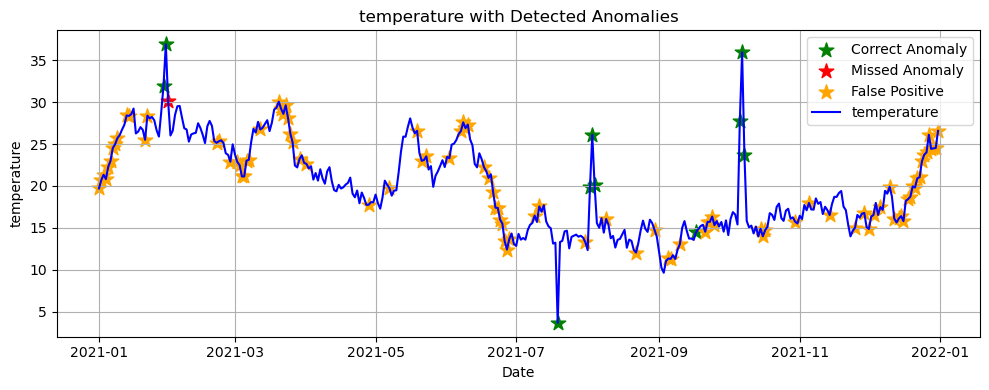

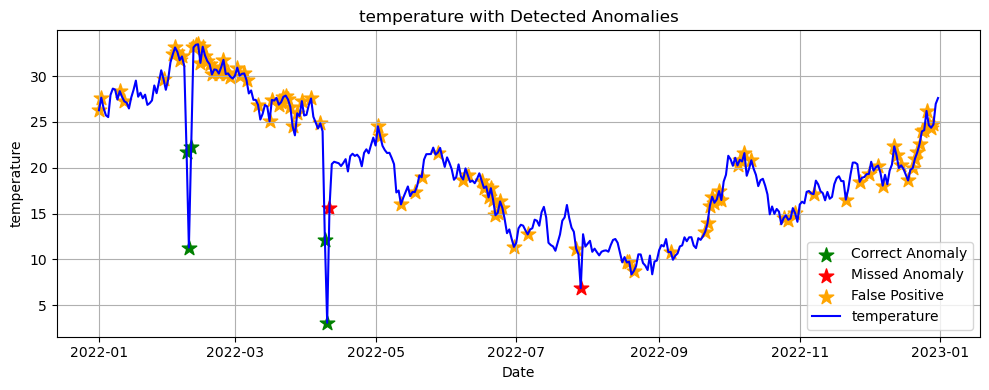

| Model | Recall | Precision | F1 | Correct | Missed | False Positives |
|-------|--------|-----------|----|---------|--------|-----------------|
| Isolation Forest | 0.833 | 0.070 | 0.129 | 15 | 3 | 200 |


In [10]:
from sklearn.ensemble import IsolationForest
if_model = IsolationForest(
    contamination="auto",
    random_state=42
)
if_model.fit(df2122)
y_pred_if = if_model.predict(df2122)
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_if, start_day=1, start_year=2021, end_day=365, end_year=2021, feature="temperature")
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_if, start_day=1, start_year=2022, end_day=365, end_year=2022, feature="temperature")
evaluate_predictions(y_true=y2122, y_pred=y_pred_if, model_name="Isolation Forest", header=True)

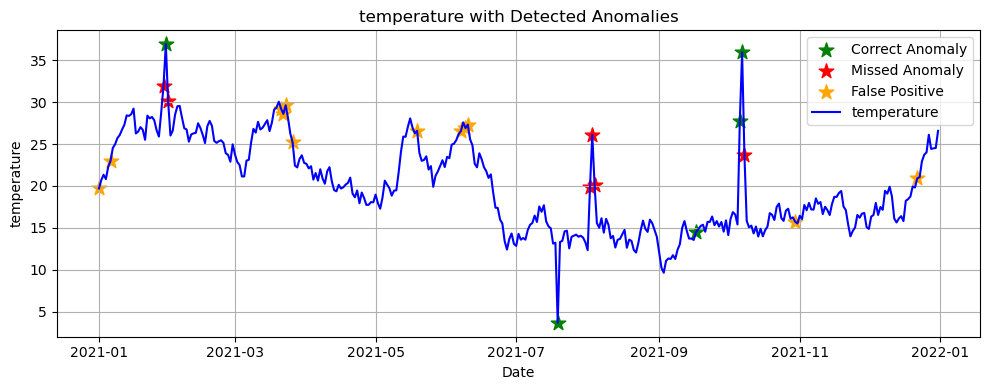

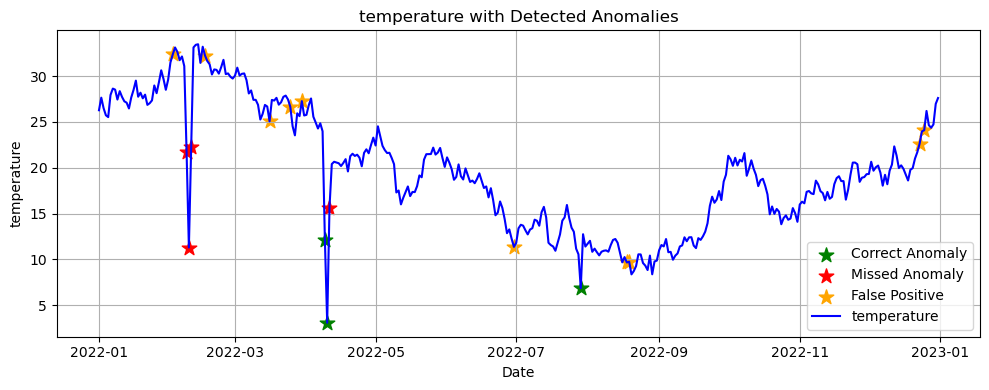

| Model | Recall | Precision | F1 | Correct | Missed | False Positives |
|-------|--------|-----------|----|---------|--------|-----------------|
| Local Outlier Factor | 0.444 | 0.267 | 0.333 | 8 | 10 | 22 |


In [11]:
from sklearn.neighbors import LocalOutlierFactor
lof_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination="auto"
)

y_pred_lof = lof_model.fit_predict(df2122)
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_lof, start_day=1, start_year=2021, end_day=365, end_year=2021, feature="temperature")
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_lof, start_day=1, start_year=2022, end_day=365, end_year=2022, feature="temperature")
evaluate_predictions(y_true=y2122, y_pred=y_pred_lof, model_name="Local Outlier Factor", header=True)

## c)Hyperparameter tuning

In [12]:
print("Isolation Forest")
for cont in [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]:
    if_model = IsolationForest(
        contamination=cont,
        random_state=42
    )
    if_model.fit(df2122)
    y_pred_if = if_model.predict(df2122)
    evaluate_predictions(y_true=y2122, y_pred=y_pred_if, model_name="Contamination "+str(cont), header=True)

Isolation Forest
| Model | Recall | Precision | F1 | Correct | Missed | False Positives |
|-------|--------|-----------|----|---------|--------|-----------------|
| Contamination 0.01 | 0.111 | 0.250 | 0.154 | 2 | 16 | 6 |
| Model | Recall | Precision | F1 | Correct | Missed | False Positives |
|-------|--------|-----------|----|---------|--------|-----------------|
| Contamination 0.03 | 0.333 | 0.273 | 0.300 | 6 | 12 | 16 |
| Model | Recall | Precision | F1 | Correct | Missed | False Positives |
|-------|--------|-----------|----|---------|--------|-----------------|
| Contamination 0.05 | 0.444 | 0.216 | 0.291 | 8 | 10 | 29 |
| Model | Recall | Precision | F1 | Correct | Missed | False Positives |
|-------|--------|-----------|----|---------|--------|-----------------|
| Contamination 0.1 | 0.556 | 0.137 | 0.220 | 10 | 8 | 63 |
| Model | Recall | Precision | F1 | Correct | Missed | False Positives |
|-------|--------|-----------|----|---------|--------|-----------------|
| Contamina

From the initial experiments, contamination values of 0.03 and 0.05 were identified as the most promising settings, as they achieved the highest F1 scores of 0.250 and 0.255, respectively. Therefore, these two contamination values were selected for further hyperparameter tuning of Isolation Forest and LOF.

In [13]:
for cont in [0.03, 0.05]:
    print("Contamination "+str(cont))
    for n_est in [100,200,300,400,500]:
        if_model = IsolationForest(
            n_estimators = n_est,
            contamination=cont,
            random_state=42
        )
        if_model.fit(df2122)
        y_pred_if = if_model.predict(df2122)
        evaluate_predictions(y_true=y2122, y_pred=y_pred_if, model_name="n_est "+str(n_est), header=True)

Contamination 0.03
| Model | Recall | Precision | F1 | Correct | Missed | False Positives |
|-------|--------|-----------|----|---------|--------|-----------------|
| n_est 100 | 0.333 | 0.273 | 0.300 | 6 | 12 | 16 |
| Model | Recall | Precision | F1 | Correct | Missed | False Positives |
|-------|--------|-----------|----|---------|--------|-----------------|
| n_est 200 | 0.278 | 0.227 | 0.250 | 5 | 13 | 17 |
| Model | Recall | Precision | F1 | Correct | Missed | False Positives |
|-------|--------|-----------|----|---------|--------|-----------------|
| n_est 300 | 0.333 | 0.273 | 0.300 | 6 | 12 | 16 |
| Model | Recall | Precision | F1 | Correct | Missed | False Positives |
|-------|--------|-----------|----|---------|--------|-----------------|
| n_est 400 | 0.333 | 0.273 | 0.300 | 6 | 12 | 16 |
| Model | Recall | Precision | F1 | Correct | Missed | False Positives |
|-------|--------|-----------|----|---------|--------|-----------------|
| n_est 500 | 0.222 | 0.182 | 0.200 | 4 | 1

In [14]:
for cont in [0.03, 0.05]:
    print("Contamination "+str(cont))
    for n_neig in [5, 10, 20, 30, 40, 50, 60, 70]:
        lof_model = LocalOutlierFactor(
            n_neighbors=n_neig,
            contamination=cont
        )
        y_pred_lof = lof_model.fit_predict(df2122)
        evaluate_predictions(y_true=y2122, y_pred=y_pred_lof, model_name="n_neig "+str(n_neig), header=True)

Contamination 0.03
| Model | Recall | Precision | F1 | Correct | Missed | False Positives |
|-------|--------|-----------|----|---------|--------|-----------------|
| n_neig 5 | 0.556 | 0.455 | 0.500 | 10 | 8 | 12 |
| Model | Recall | Precision | F1 | Correct | Missed | False Positives |
|-------|--------|-----------|----|---------|--------|-----------------|
| n_neig 10 | 0.444 | 0.364 | 0.400 | 8 | 10 | 14 |
| Model | Recall | Precision | F1 | Correct | Missed | False Positives |
|-------|--------|-----------|----|---------|--------|-----------------|
| n_neig 20 | 0.333 | 0.273 | 0.300 | 6 | 12 | 16 |
| Model | Recall | Precision | F1 | Correct | Missed | False Positives |
|-------|--------|-----------|----|---------|--------|-----------------|
| n_neig 30 | 0.278 | 0.227 | 0.250 | 5 | 13 | 17 |
| Model | Recall | Precision | F1 | Correct | Missed | False Positives |
|-------|--------|-----------|----|---------|--------|-----------------|
| n_neig 40 | 0.278 | 0.227 | 0.250 | 5 | 13

## d)Model Selection
LOF with n_neighbour 5 and contamination 0.03 was selected because it achieved the highest F1 score among the models tested. The F1 score provides a balance between recall and precision, making it suitable for selecting a model that can detect anomalies while limiting false positives.

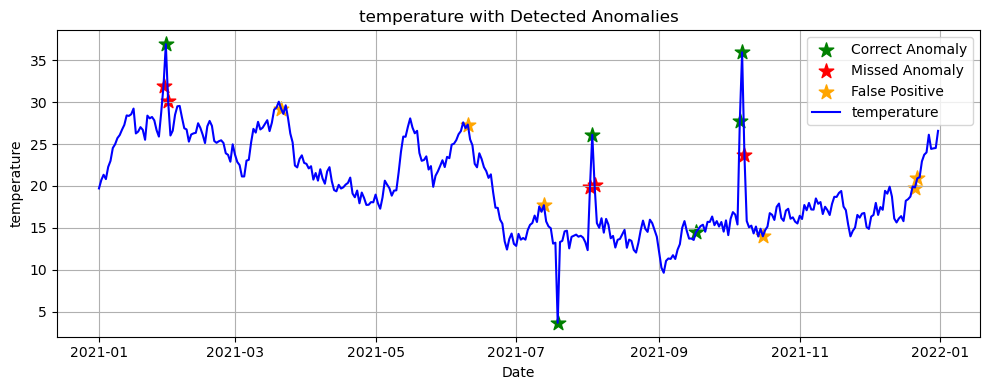

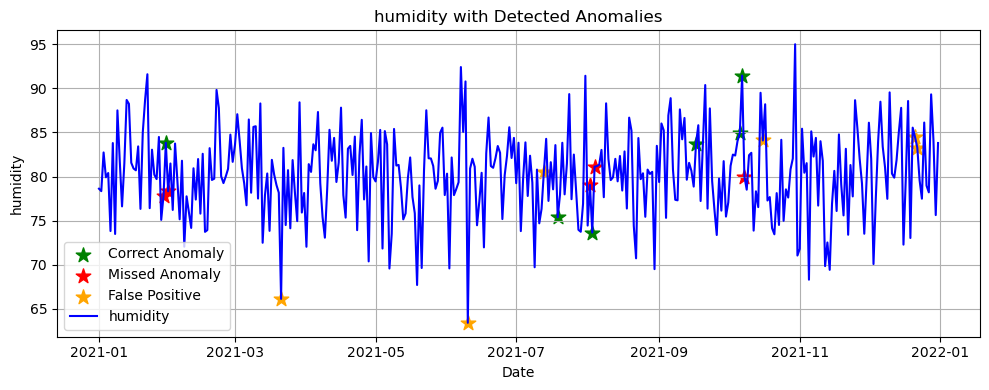

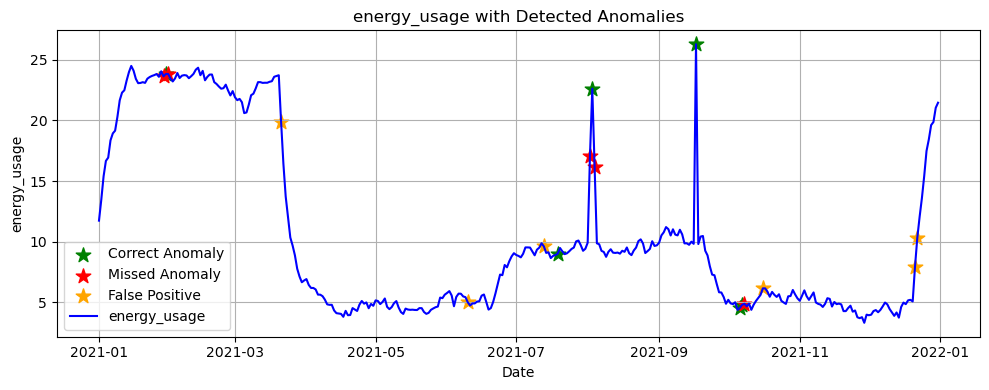

| Model | Recall | Precision | F1 | Correct | Missed | False Positives |
|-------|--------|-----------|----|---------|--------|-----------------|
| Local Outlier Factor | 0.556 | 0.455 | 0.500 | 10 | 8 | 12 |


In [15]:
lof_model = LocalOutlierFactor(
    n_neighbors=5,
    contamination=0.03
)

y_pred_lof = lof_model.fit_predict(df2122)
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_lof, start_day=1, start_year=2021, end_day=365, end_year=2021, feature="temperature")
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_lof, start_day=1, start_year=2021, end_day=365, end_year=2021, feature="humidity")
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_lof, start_day=1, start_year=2021, end_day=365, end_year=2021, feature="energy_usage")
evaluate_predictions(y_true=y2122, y_pred=y_pred_lof, model_name="Local Outlier Factor", header=True)

The LOF results show both successful and unsuccessful anomaly detections. Between January and March, three anomalies can be observed, with the middle observation having the highest temperature. LOF successfully detected the most extreme middle anomaly but missed the anomalies on either side. This suggests that the two missed anomalies were less distinct from their local neighbourhood and therefore did not have a sufficiently low local density to be classified as anomalies.

Between March and May, several false positives were identified. Although these observations did not appear to be extreme based on temperature, their humidity values were among the lowest in the dataset and the energy usage potentially shifting to low. This suggests that LOF detected them because of their local behaviour across multiple features rather than because of an extreme value in temperature alone. A similar pattern was observed for some false positives between May and July.

Around July and September, there were sudden spikes in temperature and energy usage while the surrounding observations remained relatively low. Although the temperature values themselves were not globally extreme and were similar to values normally observed during summer, they were unusual because they occurred during winter. Therefore, these observations can be considered contextual anomalies. LOF also success to detect these anomalies, suggesting that the model successfully identifying anomalies that depend on seasonal context.

Finally, an increase in energy usage was observed towards December, where LOF produced a false positive as the energy usage and temeprature increased rapidly. This may indicate that the model was sensitive to the change in local density caused by the increasing trend. It can be described as a possible limitation of the model in handling a changing seasonal or temporal pattern.


## e)Exploration
### Removed Humidity

Based on the analysis, several false positives appeared to be associated with unusually high or low humidity values. Since these observations did not necessarily show unusual temperature or energy usage, humidity may have contributed to the incorrect classifications. Therefore, an alternative feature set excluding humidity was investigated. The LOF model was retrained using temperature, energy usage, and the temporal/seasonal features to determine whether removing humidity could reduce false positives and improve anomaly detection performance.

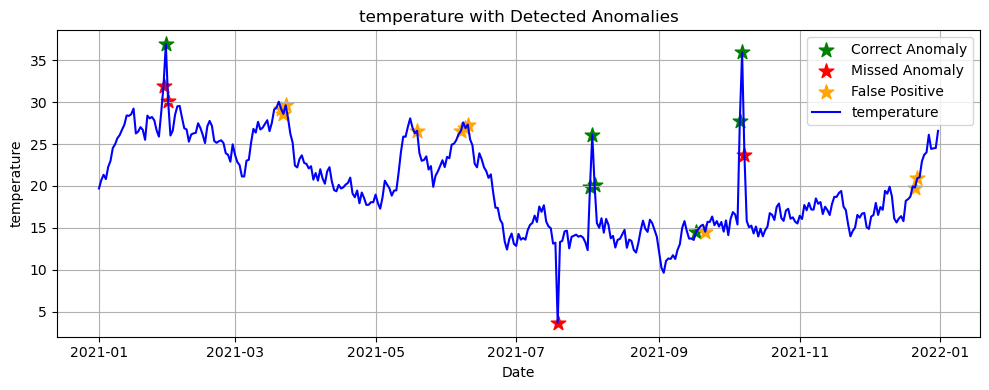

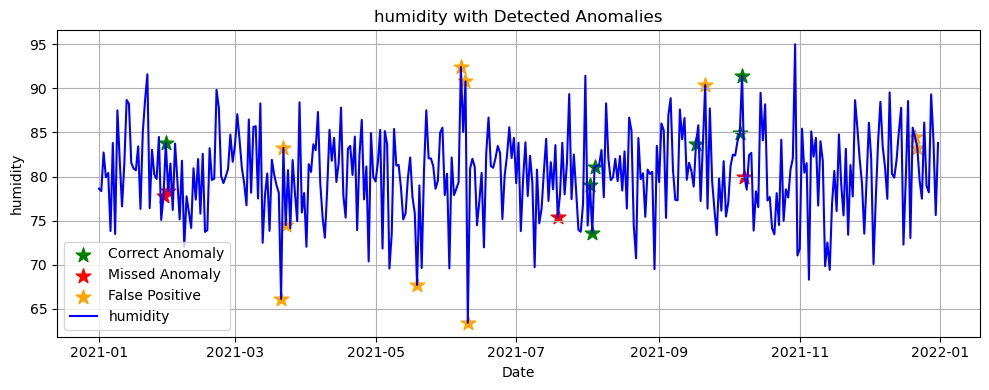

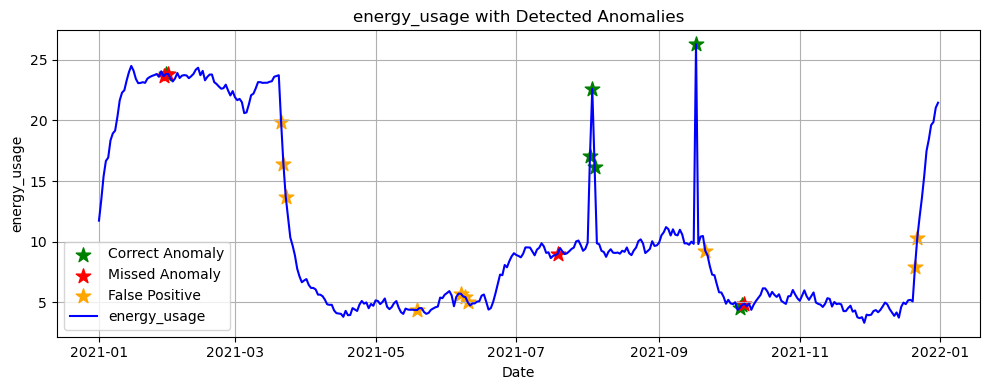

| Model | Recall | Precision | F1 | Correct | Missed | False Positives |
|-------|--------|-----------|----|---------|--------|-----------------|
| Isolation Forest | 0.500 | 0.243 | 0.327 | 9 | 9 | 28 |


In [16]:
if_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)
if_model.fit(df2122)
y_pred_if = if_model.predict(df2122)
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_if, start_day=1, start_year=2021, end_day=365, end_year=2021, feature="temperature")
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_if, start_day=1, start_year=2021, end_day=365, end_year=2021, feature="humidity")
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_if, start_day=1, start_year=2021, end_day=365, end_year=2021, feature="energy_usage")
evaluate_predictions(y_true=y2122, y_pred=y_pred_if, model_name="Isolation Forest", header=True)

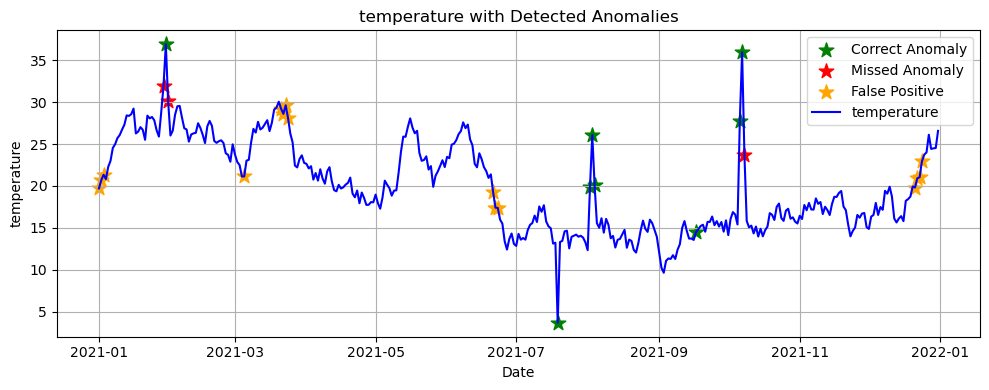

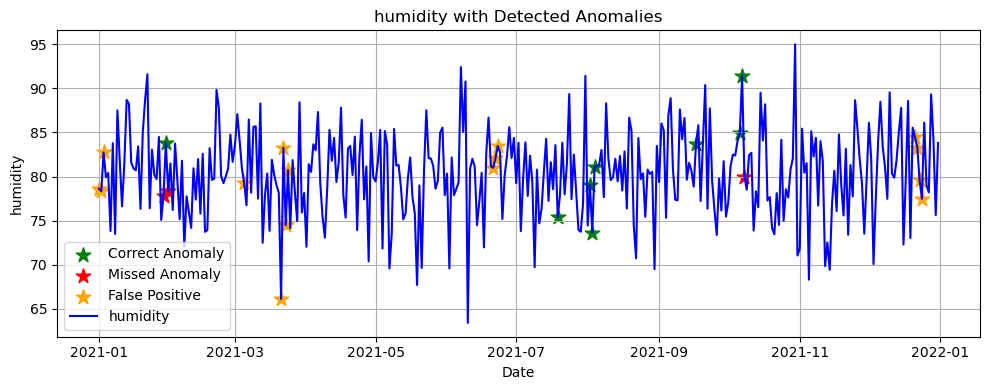

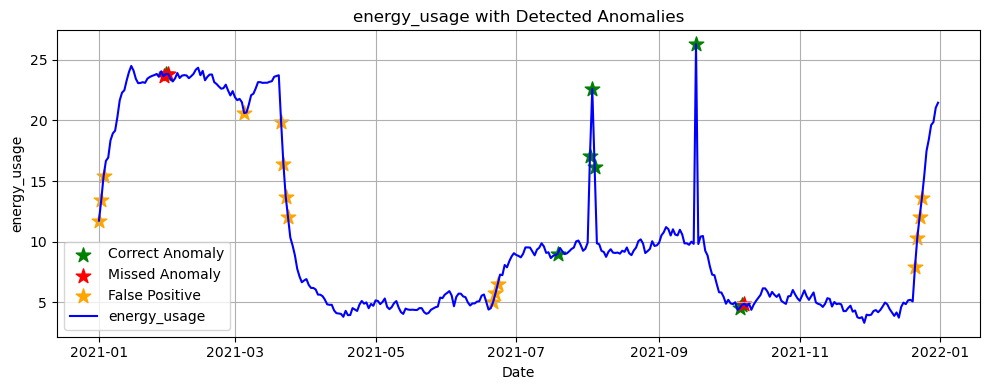

| Model | Recall | Precision | F1 | Correct | Missed | False Positives |
|-------|--------|-----------|----|---------|--------|-----------------|
| Isolation Forest | 0.611 | 0.297 | 0.400 | 11 | 7 | 26 |


In [17]:
df_ex1 = df2122.drop(columns=["humidity"])
if_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)
if_model.fit(df_ex1)
y_pred_if = if_model.predict(df_ex1)
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_if, start_day=1, start_year=2021, end_day=365, end_year=2021, feature="temperature")
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_if, start_day=1, start_year=2021, end_day=365, end_year=2021, feature="humidity")
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_if, start_day=1, start_year=2021, end_day=365, end_year=2021, feature="energy_usage")
evaluate_predictions(y_true=y2122, y_pred=y_pred_if, model_name="Isolation Forest", header=True)

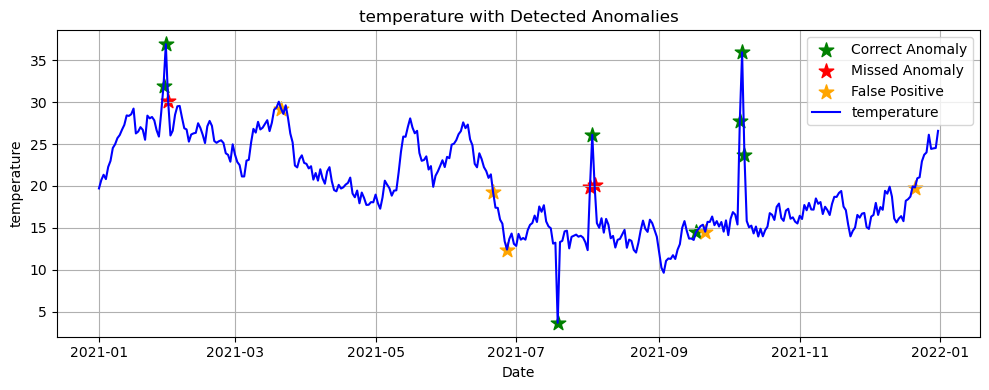

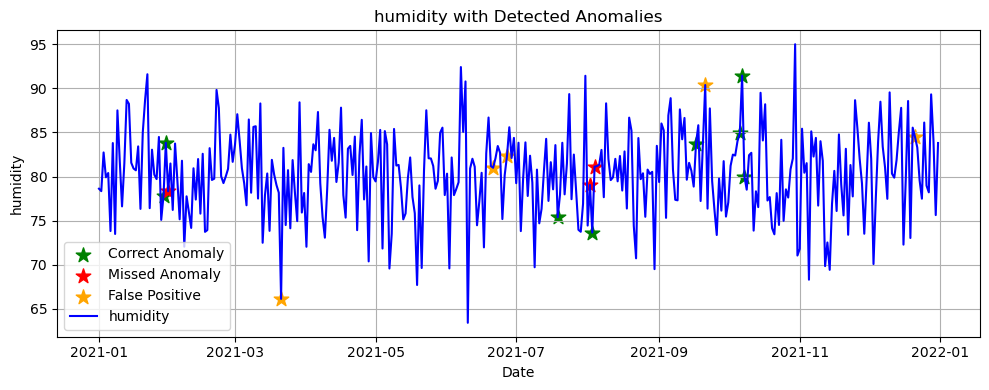

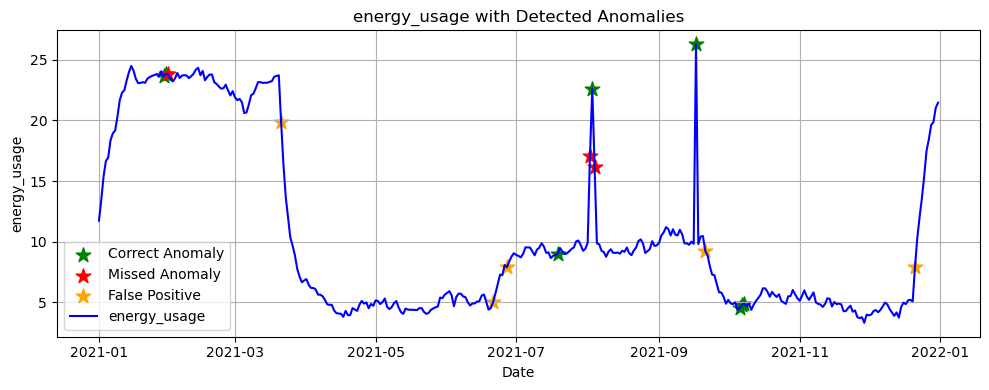

| Model | Recall | Precision | F1 | Correct | Missed | False Positives |
|-------|--------|-----------|----|---------|--------|-----------------|
| Local Outlier Factor | 0.722 | 0.591 | 0.650 | 13 | 5 | 9 |


In [18]:
lof_model = LocalOutlierFactor(
    n_neighbors=5,
    contamination=0.03
)

y_pred_lof = lof_model.fit_predict(df_ex1)
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_lof, start_day=1, start_year=2021, end_day=365, end_year=2021, feature="temperature")
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_lof, start_day=1, start_year=2021, end_day=365, end_year=2021, feature="humidity")
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_lof, start_day=1, start_year=2021, end_day=365, end_year=2021, feature="energy_usage")
evaluate_predictions(y_true=y2122, y_pred=y_pred_lof, model_name="Local Outlier Factor", header=True)

### Temperature and Energy Usage Scaled

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled = df_ex1.copy()

features = ["temperature", "energy_usage"]

df_scaled[features] = scaler.fit_transform(df_scaled[features])

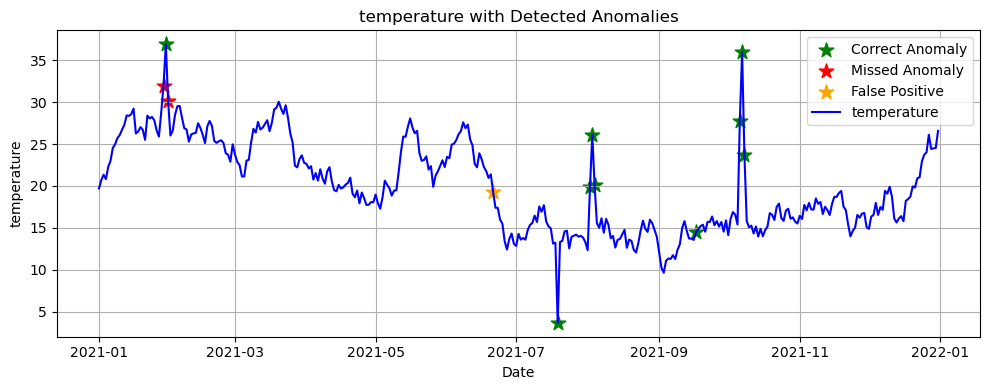

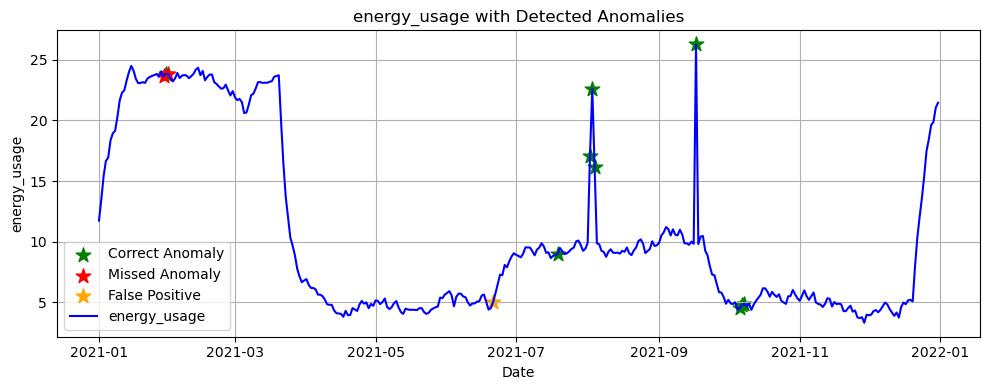

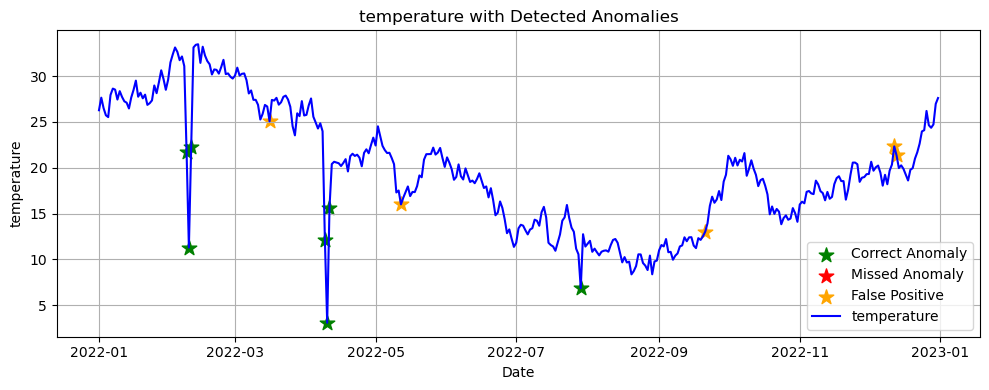

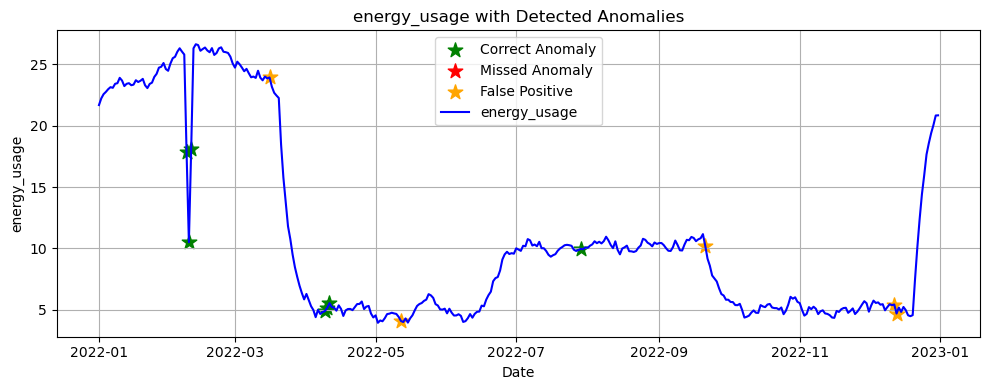

| Model | Recall | Precision | F1 | Correct | Missed | False Positives |
|-------|--------|-----------|----|---------|--------|-----------------|
| Local Outlier Factor | 0.889 | 0.727 | 0.800 | 16 | 2 | 6 |


In [20]:
lof_model = LocalOutlierFactor(
    n_neighbors=5,
    contamination=0.03
)

y_pred_lof = lof_model.fit_predict(df_scaled)
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_lof, start_day=1, start_year=2021, end_day=365, end_year=2021, feature="temperature")
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_lof, start_day=1, start_year=2021, end_day=365, end_year=2021, feature="energy_usage")
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_lof, start_day=1, start_year=2022, end_day=365, end_year=2022, feature="temperature")
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_lof, start_day=1, start_year=2022, end_day=365, end_year=2022, feature="energy_usage")
evaluate_predictions(y_true=y2122, y_pred=y_pred_lof, model_name="Local Outlier Factor", header=True)

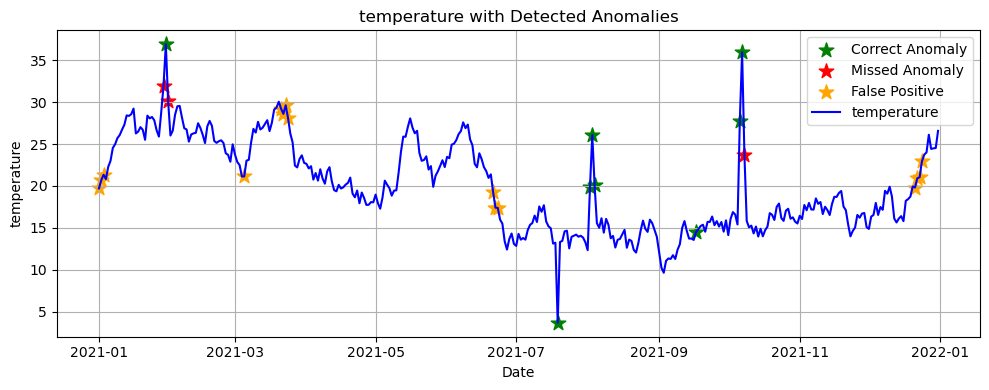

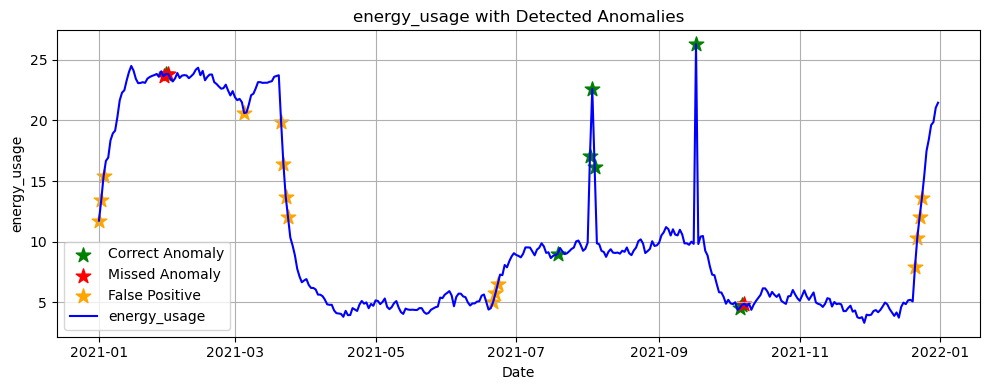

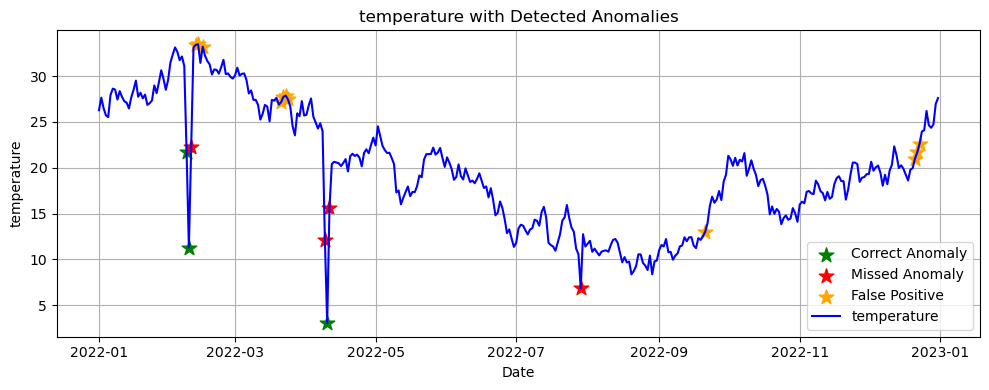

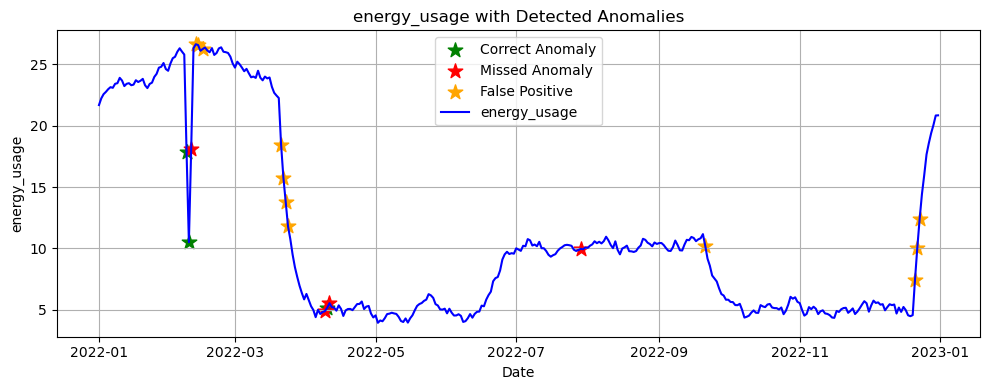

| Model | Recall | Precision | F1 | Correct | Missed | False Positives |
|-------|--------|-----------|----|---------|--------|-----------------|
| Isolation Forest | 0.611 | 0.297 | 0.400 | 11 | 7 | 26 |


In [21]:
if_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)
if_model.fit(df_scaled)
y_pred_if = if_model.predict(df_scaled)
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_if, start_day=1, start_year=2021, end_day=365, end_year=2021, feature="temperature")
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_if, start_day=1, start_year=2021, end_day=365, end_year=2021, feature="energy_usage")
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_if, start_day=1, start_year=2022, end_day=365, end_year=2022, feature="temperature")
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_if, start_day=1, start_year=2022, end_day=365, end_year=2022, feature="energy_usage")
evaluate_predictions(y_true=y2122, y_pred=y_pred_if, model_name="Isolation Forest", header=True)

### And Ensemble

In [22]:
y_pred_ensemble = np.where(
    (y_pred_if == -1) & (y_pred_lof == -1),
    -1,
    1
)
evaluate_predictions(y_true=y2122, y_pred=y_pred_ensemble, model_name="Ensemble And", header=True)

| Model | Recall | Precision | F1 | Correct | Missed | False Positives |
|-------|--------|-----------|----|---------|--------|-----------------|
| Ensemble And | 0.611 | 0.846 | 0.710 | 11 | 7 | 2 |


AND-based ensemble was also investigated, where an observation was classified as an anomaly only when both Isolation Forest and LOF identified it as anomalous. The ensemble substantially reduced false positives from 6 to 2 and increased precision from 0.727 to 0.846. However, recall decreased from 0.889 to 0.611 because several anomalies detected by LOF were not detected by Isolation Forest. Consequently, the F1 score decreased from 0.800 to 0.710. This indicates that requiring agreement between the two models produces more conservative anomaly detection, improving precision at the cost of recall.

### One Class SVM

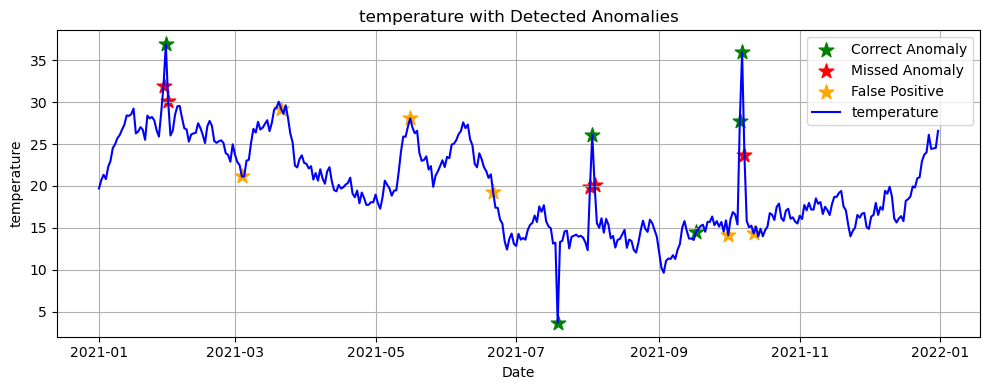

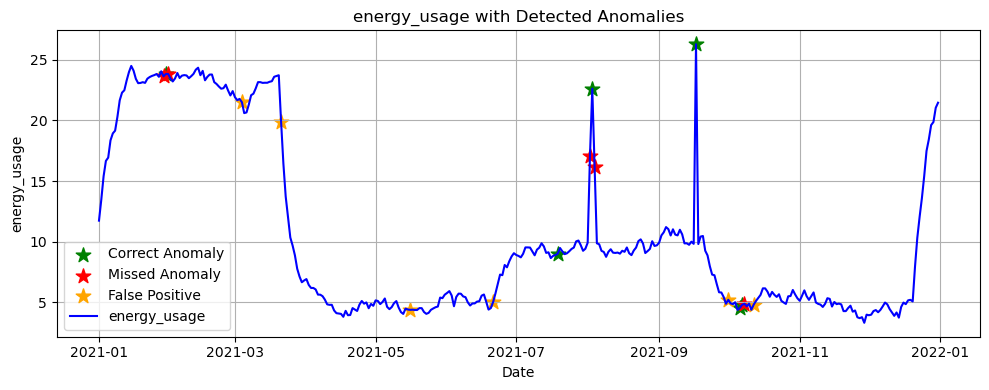

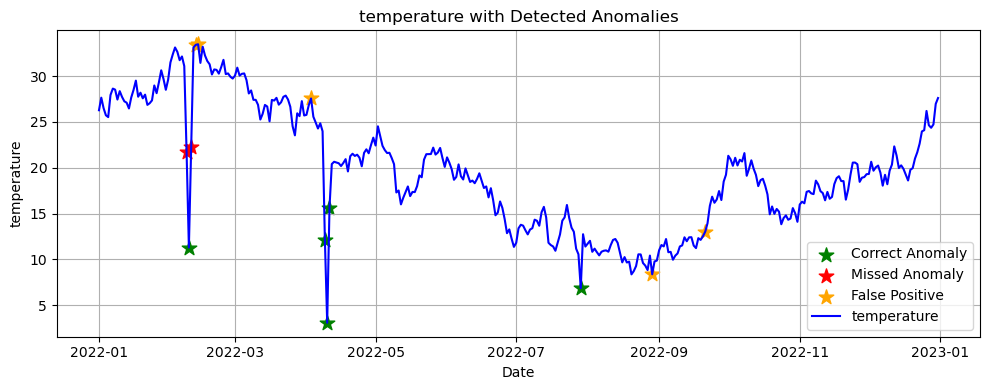

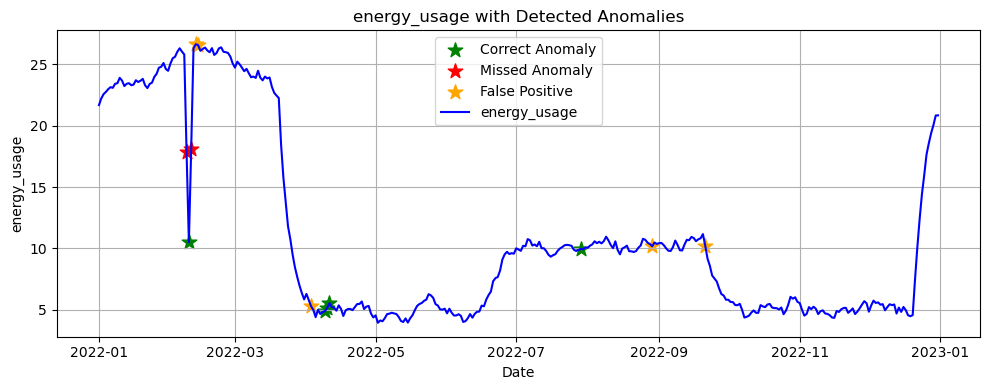

| Model | Recall | Precision | F1 | Correct | Missed | False Positives |
|-------|--------|-----------|----|---------|--------|-----------------|
| One Class SVM | 0.611 | 0.500 | 0.550 | 11 | 7 | 11 |


In [23]:
from sklearn.svm import OneClassSVM

ocsvm = OneClassSVM(
    nu=0.03,
    kernel="rbf",
    gamma="scale"
)

y_pred_ocsvm = ocsvm.fit_predict(df_scaled)
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_ocsvm, start_day=1, start_year=2021, end_day=365, end_year=2021, feature="temperature")
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_ocsvm, start_day=1, start_year=2021, end_day=365, end_year=2021, feature="energy_usage")
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_ocsvm, start_day=1, start_year=2022, end_day=365, end_year=2022, feature="temperature")
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_ocsvm, start_day=1, start_year=2022, end_day=365, end_year=2022, feature="energy_usage")
evaluate_predictions(y_true=y2122, y_pred=y_pred_ocsvm, model_name="One Class SVM", header=True)

### Vote Ensemble

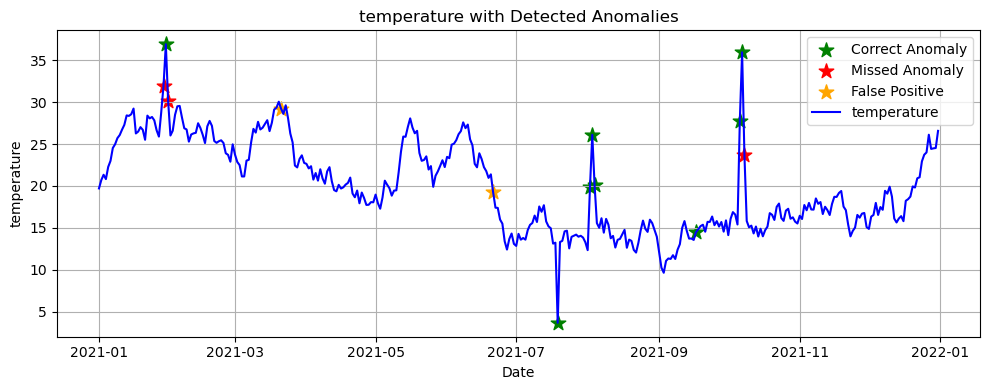

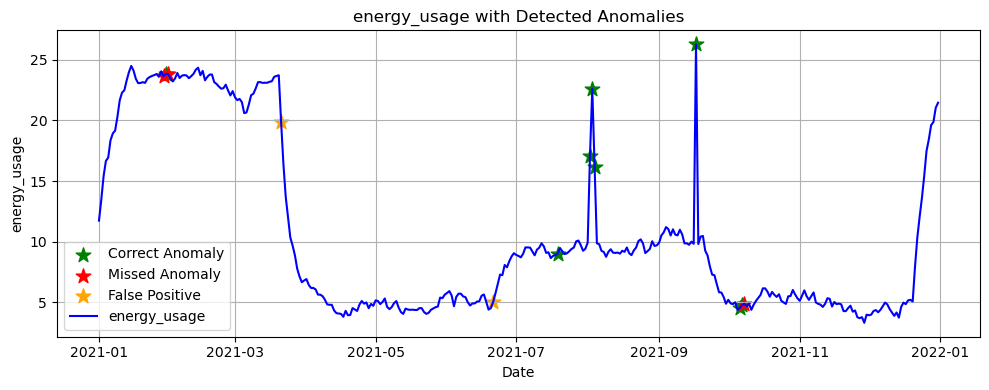

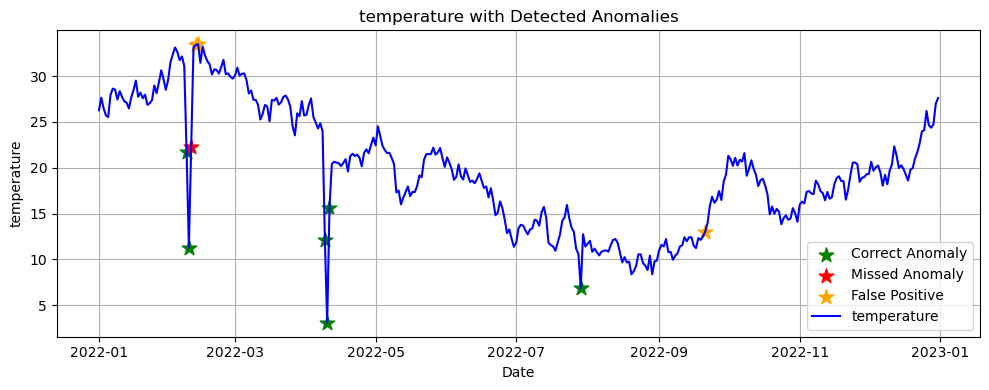

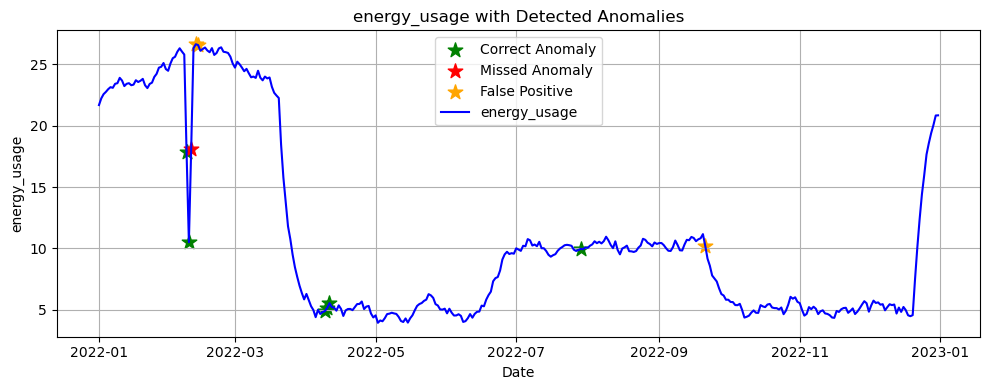

| Model | Recall | Precision | F1 | Correct | Missed | False Positives |
|-------|--------|-----------|----|---------|--------|-----------------|
| Ensemble Vote | 0.778 | 0.737 | 0.757 | 14 | 4 | 5 |


In [24]:
y_pred_ensemble2 = np.where(
    (
        (y_pred_if == -1).astype(int) +
        (y_pred_lof == -1).astype(int) +
        (y_pred_ocsvm == -1).astype(int)
    ) >= 2,
    -1,
    1
)
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_ensemble2, start_day=1, start_year=2021, end_day=365, end_year=2021, feature="temperature")
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_ensemble2, start_day=1, start_year=2021, end_day=365, end_year=2021, feature="energy_usage")
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_ensemble2, start_day=1, start_year=2022, end_day=365, end_year=2022, feature="temperature")
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_ensemble2, start_day=1, start_year=2022, end_day=365, end_year=2022, feature="energy_usage")
evaluate_predictions(y_true=y2122, y_pred=y_pred_ensemble2, model_name="Ensemble Vote", header=True)

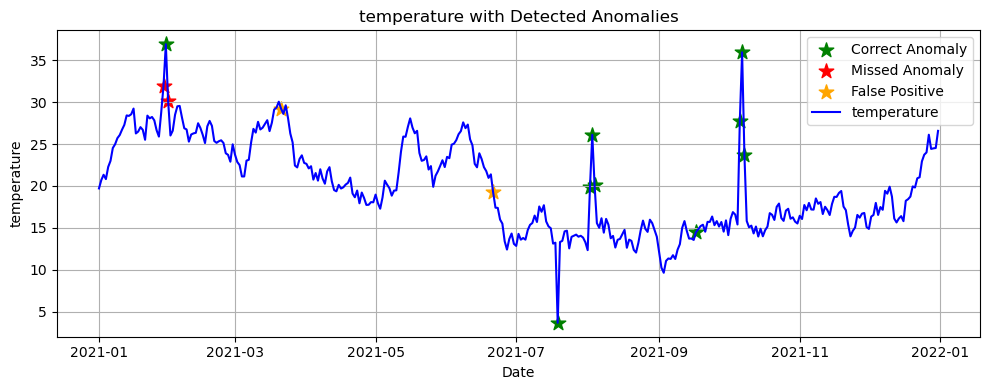

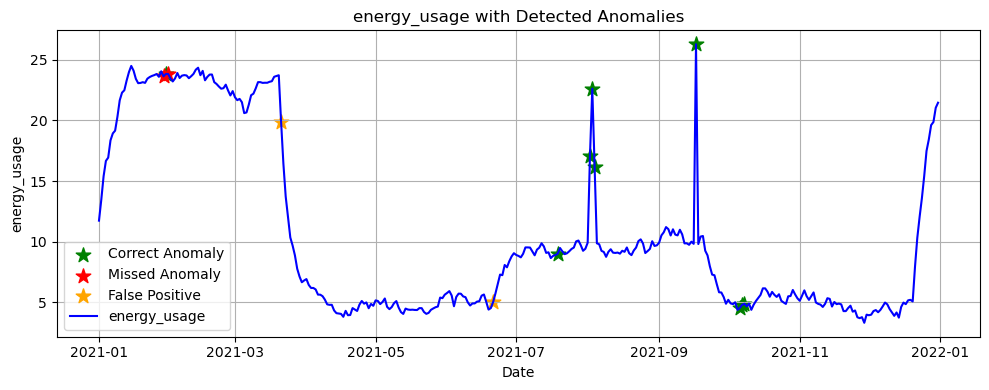

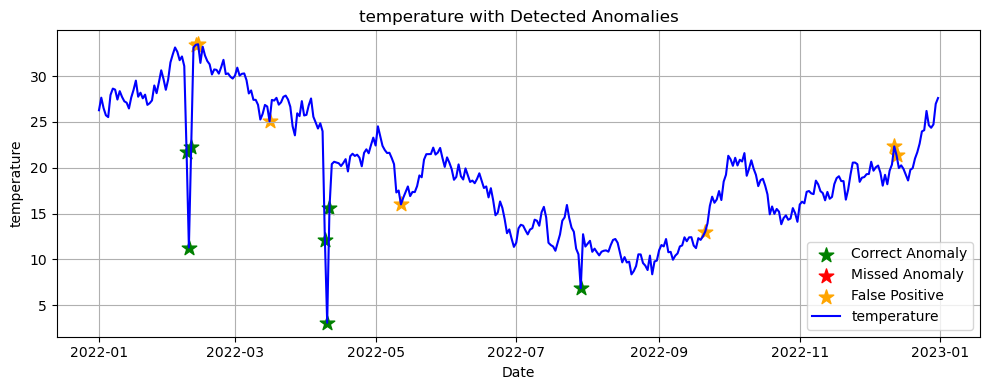

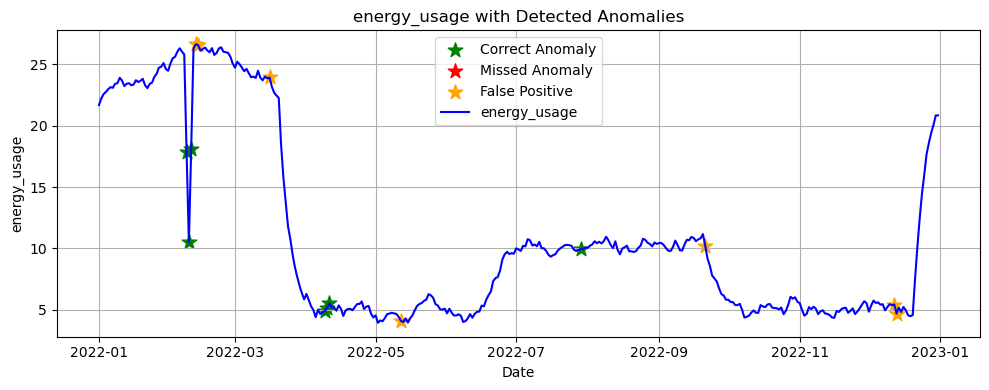

| Model | Recall | Precision | F1 | Correct | Missed | False Positives |
|-------|--------|-----------|----|---------|--------|-----------------|
| Ensemble Vote | 0.889 | 0.640 | 0.744 | 16 | 2 | 9 |


In [25]:
y_pred_ensemble3 = np.where(
    (
        2 * (y_pred_lof == -1).astype(int) +
        (y_pred_ocsvm == -1).astype(int) +
        (y_pred_if == -1).astype(int)
    ) >= 2,
    -1,
    1
)

plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_ensemble3, start_day=1, start_year=2021, end_day=365, end_year=2021, feature="temperature")
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_ensemble3, start_day=1, start_year=2021, end_day=365, end_year=2021, feature="energy_usage")
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_ensemble3, start_day=1, start_year=2022, end_day=365, end_year=2022, feature="temperature")
plot_detection(df=df_original, y_true=y2122, y_pred=y_pred_ensemble3, start_day=1, start_year=2022, end_day=365, end_year=2022, feature="energy_usage")
evaluate_predictions(y_true=y2122, y_pred=y_pred_ensemble3, model_name="Ensemble Vote", header=True)